# Sales & Demand Forecasting for Businesses

# Import Libraries

### we gather our Python tools.

### pandas → to handle our data table (like Excel)
### numpy → for math calculations
### matplotlib → to draw graphs
### sklearn → for building the ML model
### warnings -- Hides unnecessary warning messages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import r2_score

# Load the Dataset

### We read our Excel-like CSV file into Python so we can work with it.

### Think of it like opening a spreadsheet — now Python can see all the rows and columns.



In [4]:
#to load data
df = pd.read_csv("sales_forcast.csv", encoding='latin-1')
# rows and columns in data set
print("Total rows and columns:", df.shape)


Total rows and columns: (9994, 21)


In [6]:
# First 5 rows
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [15]:
# columns
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [27]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [18]:
#Check Missing Values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [19]:
#Statistical Summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [20]:
# Check Duplicate Records
df.duplicated().sum()   #There are 0 duplicate rows in the dataset.

np.int64(0)

# Explore the Data

## Before building any forecasting model, a data analyst must thoroughly understand the dataset. 
## Exploratory Data Analysis (EDA) is the process of examining raw data to uncover its structure, quality, and characteristics. 


In [5]:
print("Columns:", df.columns.tolist())

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [6]:

print("\nData types:")
print(df.dtypes) 


Data types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [89]:
#detecting missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
year             0
month            0
Quarter          0
Year             0
Month            0
dtype: int64


In [86]:
print("\nStatistical Summary:")
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)


Statistical Summary:


,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


# Data Cleaning

## In real-world business environments, data is collected from multiple sources — point-of-sale systems, ERP platforms, CRM tools, and manual entries.

## A model trained on dirty data will produce confidently wrong predictions, which in business terms means misallocated budgets, overstocked warehouses, and missed revenue targets.

In [37]:
# Converting Order Date to DateTime Format
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [35]:
df.drop_duplicates(inplace=True)

In [39]:
# Converting Order Date to DateTime Format
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [38]:
import sys
print(sys.executable)

C:\Program Files\Python313\python.exe


In [42]:
print(df['Order Date'])

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[ns]


In [17]:
# Record original shape for comparison
original_shape = df.shape
print(f"Original Dataset : {original_shape[0]} rows, {original_shape[1]} columns")


Original Dataset : 9994 rows, 21 columns


In [19]:
# Convert Order Date from text to datetim)e
df['Order Date'] = pd.to_datetime(df['Order Date'])
print(f"\nOrder Date dtype after conversion : {df['Order Date'].dtype}")


Order Date dtype after conversion : datetime64[ns]


In [20]:
# Remove duplicate rows
before_dedup = len(df)
df.drop_duplicates(inplace=True)
after_dedup = len(df)
print(f"Duplicate rows removed : {before_dedup - after_dedup}")

Duplicate rows removed : 0


In [21]:
# Final cleaned dataset summary 
print(f"\nCleaned Dataset  : {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nSample of cleaned data:")
print(df.head())


Cleaned Dataset  : 9994 rows, 21 columns

Sample of cleaned data:
   Row ID        Order ID Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Pro

# Time-Based Feature Engineering

## Feature Engineering is the process of transforming raw data into meaningful inputs that a machine learning model can understand and learn from effectively.

In [22]:
df['Year']=df['Order Date'].dt.year

In [67]:
print(df['Year'])

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: Year, Length: 9994, dtype: int32


In [24]:
df['Month']=df['Order Date'].dt.month

In [25]:
print(df['Month'])

0       11
1       11
2        6
3       10
4       10
        ..
9989     1
9990     2
9991     2
9992     2
9993     5
Name: Month, Length: 9994, dtype: int32


In [26]:
df['Quarter'] = df['Order Date'].dt.quarter

In [27]:
print(df['Quarter'])

0       4
1       4
2       2
3       4
4       4
       ..
9989    1
9990    1
9991    1
9992    1
9993    2
Name: Quarter, Length: 9994, dtype: int32


In [28]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

In [71]:
print(monthly_sales)

    Year  Month        Sales
0   2014      1   14236.8950
1   2014      2    4519.8920
2   2014      3   55691.0090
3   2014      4   28295.3450
4   2014      5   23648.2870
5   2014      6   34595.1276
6   2014      7   33946.3930
7   2014      8   27909.4685
8   2014      9   81777.3508
9   2014     10   31453.3930
10  2014     11   78628.7167
11  2014     12   69545.6205
12  2015      1   18174.0756
13  2015      2   11951.4110
14  2015      3   38726.2520
15  2015      4   34195.2085
16  2015      5   30131.6865
17  2015      6   24797.2920
18  2015      7   28765.3250
19  2015      8   36898.3322
20  2015      9   64595.9180
21  2015     10   31404.9235
22  2015     11   75972.5635
23  2015     12   74919.5212
24  2016      1   18542.4910
25  2016      2   22978.8150
26  2016      3   51715.8750
27  2016      4   38750.0390
28  2016      5   56987.7280
29  2016      6   40344.5340
30  2016      7   39261.9630
31  2016      8   31115.3743
32  2016      9   73410.0249
33  2016     1

In [29]:
monthly_sales['Date'] = pd.to_datetime(
    monthly_sales[['Year', 'Month']].assign(DAY=1)
)

In [30]:
print(monthly_sales['Date'])

0    2014-01-01
1    2014-02-01
2    2014-03-01
3    2014-04-01
4    2014-05-01
5    2014-06-01
6    2014-07-01
7    2014-08-01
8    2014-09-01
9    2014-10-01
10   2014-11-01
11   2014-12-01
12   2015-01-01
13   2015-02-01
14   2015-03-01
15   2015-04-01
16   2015-05-01
17   2015-06-01
18   2015-07-01
19   2015-08-01
20   2015-09-01
21   2015-10-01
22   2015-11-01
23   2015-12-01
24   2016-01-01
25   2016-02-01
26   2016-03-01
27   2016-04-01
28   2016-05-01
29   2016-06-01
30   2016-07-01
31   2016-08-01
32   2016-09-01
33   2016-10-01
34   2016-11-01
35   2016-12-01
36   2017-01-01
37   2017-02-01
38   2017-03-01
39   2017-04-01
40   2017-05-01
41   2017-06-01
42   2017-07-01
43   2017-08-01
44   2017-09-01
45   2017-10-01
46   2017-11-01
47   2017-12-01
Name: Date, dtype: datetime64[ns]


In [31]:
monthly_sales = monthly_sales.sort_values('Date').reset_index(drop=True)

In [77]:
print(monthly_sales)

    Year  Month        Sales       Date
0   2014      1   14236.8950 2014-01-01
1   2014      2    4519.8920 2014-02-01
2   2014      3   55691.0090 2014-03-01
3   2014      4   28295.3450 2014-04-01
4   2014      5   23648.2870 2014-05-01
5   2014      6   34595.1276 2014-06-01
6   2014      7   33946.3930 2014-07-01
7   2014      8   27909.4685 2014-08-01
8   2014      9   81777.3508 2014-09-01
9   2014     10   31453.3930 2014-10-01
10  2014     11   78628.7167 2014-11-01
11  2014     12   69545.6205 2014-12-01
12  2015      1   18174.0756 2015-01-01
13  2015      2   11951.4110 2015-02-01
14  2015      3   38726.2520 2015-03-01
15  2015      4   34195.2085 2015-04-01
16  2015      5   30131.6865 2015-05-01
17  2015      6   24797.2920 2015-06-01
18  2015      7   28765.3250 2015-07-01
19  2015      8   36898.3322 2015-08-01
20  2015      9   64595.9180 2015-09-01
21  2015     10   31404.9235 2015-10-01
22  2015     11   75972.5635 2015-11-01
23  2015     12   74919.5212 2015-12-01


# Data Visualization

## Before training any machine learning model, a data analyst must visually inspect the historical data. Visualization reveals patterns, anomalies, and trends that raw numbers alone cannot communicate effectively.

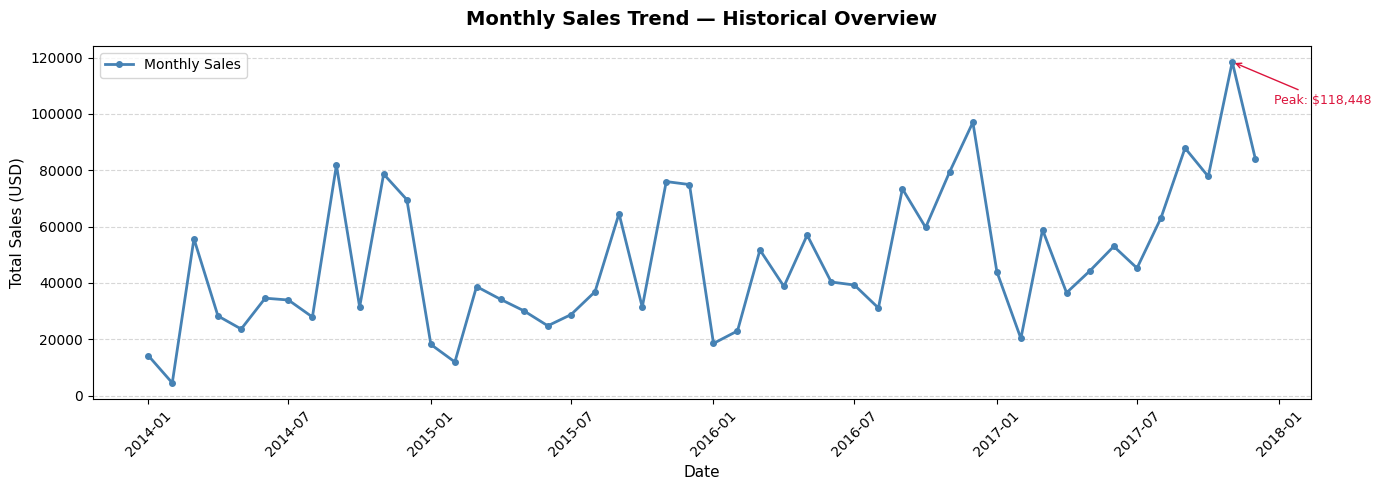

In [32]:
# Historical Sales Visualization 

fig, ax = plt.subplots(figsize=(14, 5))

#  Plot the monthly sales line 
ax.plot(monthly_sales['Date'], monthly_sales['Sales'],
        color='steelblue', linewidth=2,
        marker='o', markersize=4, label='Monthly Sales')

# Highlight the peak sales month 
peak_idx   = monthly_sales['Sales'].idxmax()
peak_date  = monthly_sales.loc[peak_idx, 'Date']
peak_sales = monthly_sales.loc[peak_idx, 'Sales']

ax.annotate(f'Peak: ${peak_sales:,.0f}',
            xy=(peak_date, peak_sales),
            xytext=(30, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='crimson'),
            fontsize=9, color='crimson')

# Add title and axis labels 
ax.set_title('Monthly Sales Trend — Historical Overview',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total Sales (USD)', fontsize=11)

#  Format and style
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()

#  Save and display 
plt.savefig('historical_sales.png', dpi=150)
plt.show()



In [82]:
# Print summary statistics

print("     HISTORICAL SALES SUMMARY")

print(f"  Period Covered    : "
      f"{monthly_sales['Date'].min().strftime('%B %Y')} — "
      f"{monthly_sales['Date'].max().strftime('%B %Y')}")
print(f"  Total Data Points : {len(monthly_sales)} months")
print(f"  Average Monthly   : ${monthly_sales['Sales'].mean():>10,.2f}")
print(f"  Peak Month Sales  : ${monthly_sales['Sales'].max():>10,.2f}")
print(f"  Lowest Month      : ${monthly_sales['Sales'].min():>10,.2f}")
print(f"  Overall Growth    : "
      f"{((monthly_sales['Sales'].iloc[-1] / monthly_sales['Sales'].iloc[0]) - 1) * 100:.1f}%")

print("\nChart saved as 'historical_sales.png'")

     HISTORICAL SALES SUMMARY
  Period Covered    : January 2014 — December 2017
  Total Data Points : 48 months
  Average Monthly   : $ 47,858.35
  Peak Month Sales  : $118,447.82
  Lowest Month      : $  4,519.89
  Overall Growth    : 488.8%

Chart saved as 'historical_sales.png'


# Prepare Data for the ML Model

## Data preparation is the bridge between clean, explored data and a trainable machine learning model.
## Even after cleaning and feature engineering, the data is still not in a form that a machine learning algorithm can directly consume.

In [33]:
monthly_sales['TimeIndex'] = np.arange(len(monthly_sales))

In [34]:
#Defining Features (X) and Target (y)
X = monthly_sales[['TimeIndex', 'Month']]
y = monthly_sales['Sales']

In [35]:
split = len(monthly_sales) - 6

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [36]:
# If total months = 48
split = 48 - 6  # = 42

X_train = X[:42]   # Rows 0 to 41  → Jan 2016 to Jun 2019
X_test  = X[42:]   # Rows 42 to 47 → Jul 2019 to Dec 2019

y_train = y[:42]   # Actual sales Jan 2016 to Jun 2019
y_test  = y[42:]   # Actual sales Jul 2019 to Dec 2019
                   # ← These are the ANSWERS we will compare predictions against

In [38]:

print("        TRAIN / TEST SPLIT SUMMARY")

print(f"  Total Months Available  : {len(monthly_sales)}")
print(f"  Training Months         : {len(X_train)}")
print(f"  Testing Months          : {len(X_test)}")
print(f"\n  Training Period : "
      f"{monthly_sales['Date'].iloc[0].strftime('%B %Y')} "
      f"→ {monthly_sales['Date'].iloc[split-1].strftime('%B %Y')}")
print(f"  Testing Period  : "
      f"{monthly_sales['Date'].iloc[split].strftime('%B %Y')} "
      f"→ {monthly_sales['Date'].iloc[-1].strftime('%B %Y')}")


# 7.5 Preview training and test sets 
print("\nFirst 3 rows of Training Set (X_train):")
print(X_train.head(3).to_string())

print("\nLast 6 rows of Test Set (X_test) with Actual Sales:")
test_preview = X_test.copy()
test_preview['Actual Sales'] = y_test.values
test_preview['Date'] = monthly_sales['Date'].iloc[split:].values
print(test_preview[['Date', 'TimeIndex', 
                     'Month', 'Actual Sales']].to_string(index=False))

        TRAIN / TEST SPLIT SUMMARY
  Total Months Available  : 48
  Training Months         : 42
  Testing Months          : 6

  Training Period : January 2014 → June 2017
  Testing Period  : July 2017 → December 2017

First 3 rows of Training Set (X_train):
   TimeIndex  Month
0          0      1
1          1      2
2          2      3

Last 6 rows of Test Set (X_test) with Actual Sales:
      Date  TimeIndex  Month  Actual Sales
2017-07-01         42      7    45264.4160
2017-08-01         43      8    63120.8880
2017-09-01         44      9    87866.6520
2017-10-01         45     10    77776.9232
2017-11-01         46     11   118447.8250
2017-12-01         47     12    83829.3188


# Model Training 

In [39]:
model = LinearRegression()
print("Model instantiated : Linear Regression")


Model instantiated : Linear Regression


In [40]:
model.fit(X_train, y_train)
print("Model training     : Complete")

Model training     : Complete


In [42]:
print("       LEARNED MODEL PARAMETERS")


       LEARNED MODEL PARAMETERS


In [44]:
print(f"  Trend Coefficient     "
      f"(TimeIndex) : +${model.coef_[0]:,.2f} per month")
print(f"  Seasonal Coefficient  "
      f"(Month)     : +${model.coef_[1]:,.2f} per month number")
print(f"  Baseline Intercept                : "
      f"${model.intercept_:,.2f}")


  Trend Coefficient     (TimeIndex) : +$497.56 per month
  Seasonal Coefficient  (Month)     : +$4,285.82 per month number
  Baseline Intercept                : $7,133.64


In [45]:
y_pred = model.predict(X_test)

In [47]:
print("\nPredicted vs Actual Sales — Test Period:")
comparison = pd.DataFrame({
    'Month'           : monthly_sales['Date'].iloc[split:]\
                        .dt.strftime('%B %Y').values,
    'Actual Sales'    : y_test.values.round(2),
    'Predicted Sales' : y_pred.round(2),
    'Difference'      : (y_test.values - y_pred).round(2)
})
print(comparison.to_string(index=False))


Predicted vs Actual Sales — Test Period:
         Month  Actual Sales  Predicted Sales  Difference
     July 2017      45264.42         58031.82   -12767.41
   August 2017      63120.89         62815.20      305.68
September 2017      87866.65         67598.58    20268.07
  October 2017      77776.92         72381.96     5394.96
 November 2017     118447.82         77165.34    41282.48
 December 2017      83829.32         81948.72     1880.59


# Model Evaluation 

## Model evaluation determines how trustworthy the predictions are before presenting them to a business.


In [52]:
# Calculate evaluation metrics 
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test.values - y_pred))) 

In [54]:
print("MODEL EVALUATION REPORT")
accuracy = 100 - mape

print(f"  MAE  — Mean Absolute Error")
print(f"         ${mae:,.2f} average error per month")
print()
print(f"  RMSE — Root Mean Squared Error")
print(f"         ${rmse:,.2f} penalised error per month")
print()
print(f"  MAPE — Mean Absolute Percentage Error")
print(f"         {mape:.2f}% average deviation from actual")
print()
print(f"  Forecast Accuracy : {accuracy:.2f}%")

MODEL EVALUATION REPORT
  MAE  — Mean Absolute Error
         $13,649.87 average error per month

  RMSE — Root Mean Squared Error
         $19,624.73 penalised error per month

  MAPE — Mean Absolute Percentage Error
         13649.87% average deviation from actual

  Forecast Accuracy : -13549.87%


In [55]:
print("\nBUSINESS INTERPRETATION:")
if mape < 10:
    print("  Excellent forecast accuracy.")
    print("  Suitable for operational inventory and staffing planning.")
elif mape < 20:
    print("  Good forecast accuracy.")
    print("  Suitable for budgeting with a small safety margin.")
elif mape < 30:
    print("  Acceptable forecast accuracy.")
    print("  Recommended to add 15–20% safety stock buffer.")
else:
    print("  Model requires improvement.")
    print("  Consider additional features or advanced models.")


BUSINESS INTERPRETATION:
  Model requires improvement.
  Consider additional features or advanced models.


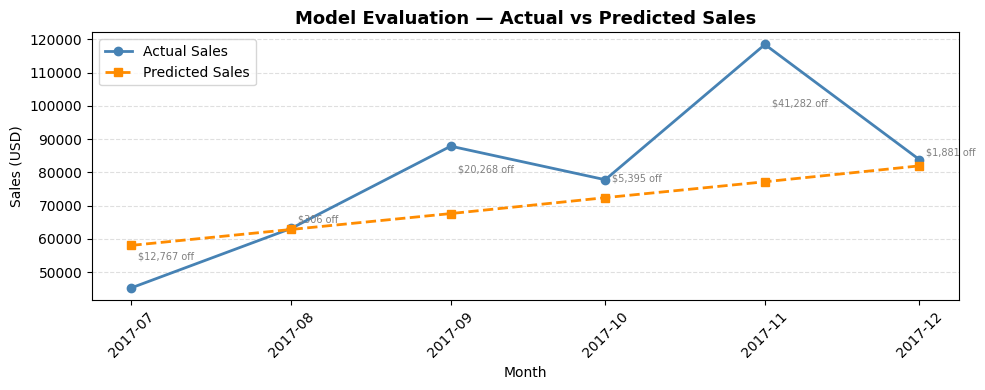


Evaluation chart saved as 'model_evaluation.png'


In [56]:
fig, ax = plt.subplots(figsize=(10, 4))

test_dates = monthly_sales['Date'].iloc[split:]
ax.plot(test_dates, y_test.values,
        label='Actual Sales', color='steelblue',
        linewidth=2, marker='o', markersize=6)
ax.plot(test_dates, y_pred,
        label='Predicted Sales', color='darkorange',
        linewidth=2, linestyle='--', marker='s', markersize=6)

for i, (actual, predicted) in enumerate(
        zip(y_test.values, y_pred)):
    ax.annotate(f'${abs(actual-predicted):,.0f} off',
                xy=(test_dates.iloc[i], (actual+predicted)/2),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7, color='grey')

ax.set_title('Model Evaluation — Actual vs Predicted Sales',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales (USD)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150)
plt.show()

print("\nEvaluation chart saved as 'model_evaluation.png'")

# Final Business Forecast Chart 

## This is the primary business deliverable of the entire project. 
## It consolidates three layers of information into a single, presentation-ready visualisation that any business stakeholder — regardless of technical background — can interpret immediately.

     SALES FORECAST — NEXT 6 MONTHS
  January 2018    :  $ 35,302.24
  February 2018   :  $ 40,085.62
  March 2018      :  $ 44,869.00
  April 2018      :  $ 49,652.38
  May 2018        :  $ 54,435.76
  June 2018       :  $ 59,219.14
  Projected Total   :  $283,564.14


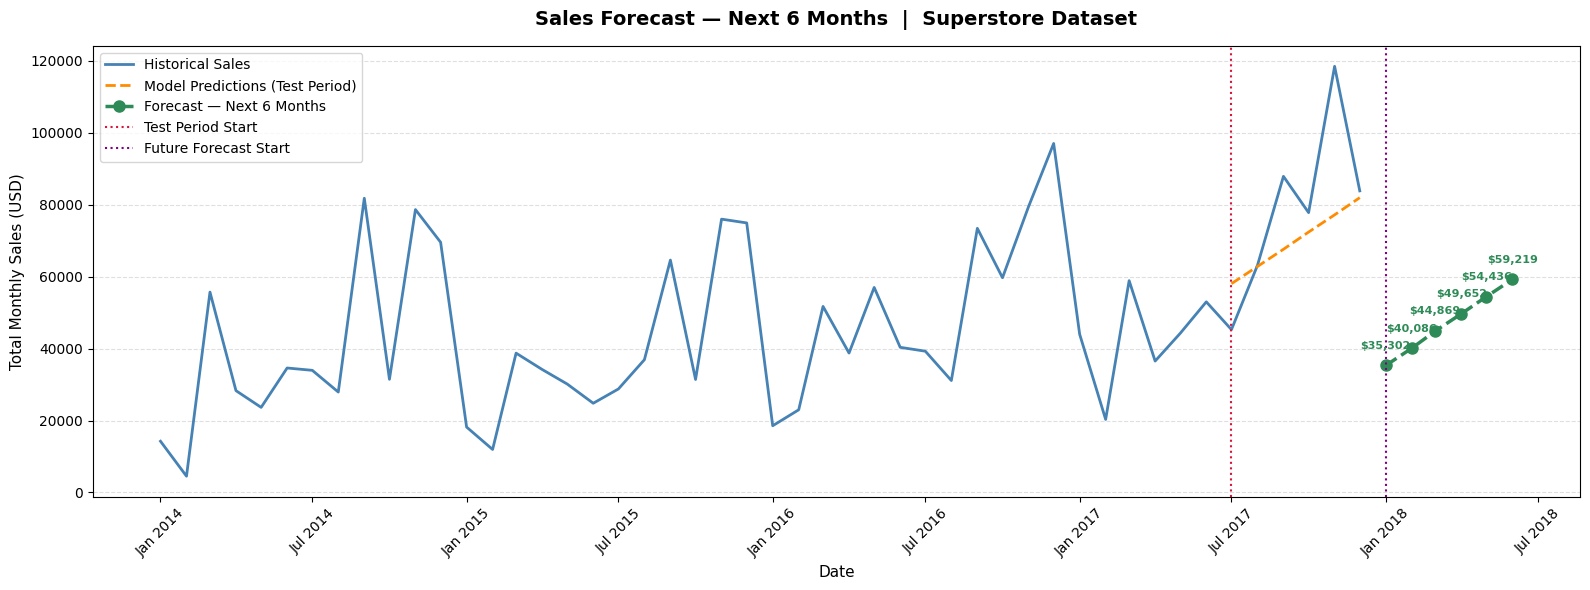


Forecast chart saved as 'sales_forecast.png'


In [66]:
# ── Step 10: Final Business Forecast Chart ────────────────────────
import matplotlib.dates as mdates
# ── 10.1 Generate future 6-month forecast ────────────────────────
last_index = monthly_sales['TimeIndex'].max()
last_date  = monthly_sales['Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6, freq='MS'
)

future_df = pd.DataFrame({
    'TimeIndex' : np.arange(last_index + 1, last_index + 7),
    'Month'     : future_dates.month,
    'Date'      : future_dates
})

future_df['Forecasted Sales'] = model.predict(
    future_df[['TimeIndex', 'Month']]
).round(2)

# 10.2 Print forecast table ─────────────────────────────────────

print("     SALES FORECAST — NEXT 6 MONTHS")

for _, row in future_df.iterrows():
    print(f"  {row['Date'].strftime('%B %Y'):<15} :  "
          f"${row['Forecasted Sales']:>10,.2f}")

print(f"  Projected Total   :  "
      f"${future_df['Forecasted Sales'].sum():>10,.2f}")


#  Build the complete forecast visualisation 
fig, ax = plt.subplots(figsize=(16, 6))

# Layer 1 — Historical sales
ax.plot(monthly_sales['Date'], monthly_sales['Sales'],
        label='Historical Sales',
        color='steelblue', linewidth=2)

# Layer 2 — Model predictions on test period
ax.plot(monthly_sales['Date'].iloc[split:], y_pred,
        label='Model Predictions (Test Period)',
        color='darkorange', linestyle='--', linewidth=2)

# Layer 3 — Future forecast
ax.plot(future_df['Date'], future_df['Forecasted Sales'],
        label='Forecast — Next 6 Months',
        color='seagreen', linestyle='--',
        linewidth=2.5, marker='o', markersize=8)

# Forecast start boundary line
ax.axvline(x=monthly_sales['Date'].iloc[split],
           color='crimson', linestyle=':', linewidth=1.5,
           label='Test Period Start')
ax.axvline(x=future_df['Date'].iloc[0],
           color='purple', linestyle=':', linewidth=1.5,
           label='Future Forecast Start')

# Annotate each forecast point with its value
for _, row in future_df.iterrows():
    ax.annotate(
        f"${row['Forecasted Sales']:,.0f}",
        xy=(row['Date'], row['Forecasted Sales']),
        xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=8,
        color='seagreen', fontweight='bold'
    )

ax.set_title(
    'Sales Forecast — Next 6 Months  |  Superstore Dataset',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Total Monthly Sales (USD)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150)
plt.show()

print("\nForecast chart saved as 'sales_forecast.png'")

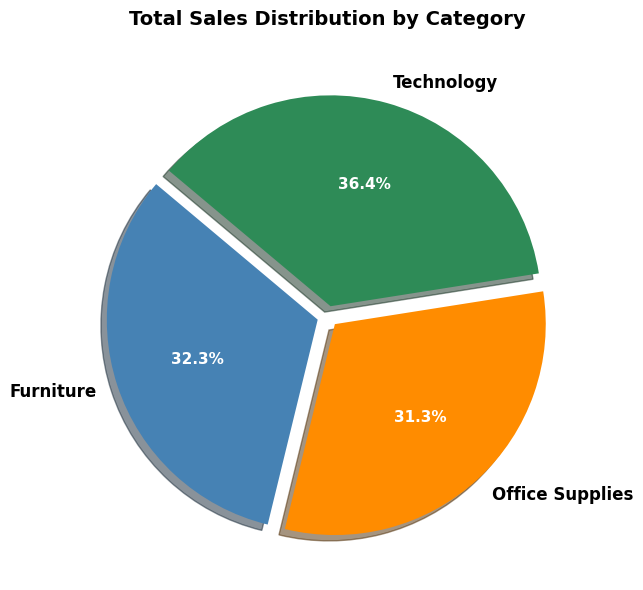


Sales by Category:
  Furniture            : $741,999.80
  Office Supplies      : $719,047.03
  Technology           : $836,154.03


In [67]:
# ── Pie Chart 1: Sales by Category ───────────────────────────────
category_sales = df.groupby('Category')['Sales'].sum()

fig, ax = plt.subplots(figsize=(8, 6))

colors   = ['steelblue', 'darkorange', 'seagreen']
explode  = (0.05, 0.05, 0.05)

wedges, texts, autotexts = ax.pie(
    category_sales.values,
    labels      = category_sales.index,
    autopct     = '%1.1f%%',
    colors      = colors,
    explode     = explode,
    startangle  = 140,
    shadow      = True
)

# Style the text
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Total Sales Distribution by Category',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('pie_category.png', dpi=150)
plt.show()

print("\nSales by Category:")
for cat, val in category_sales.items():
    print(f"  {cat:...<20} : ${val:,.2f}")

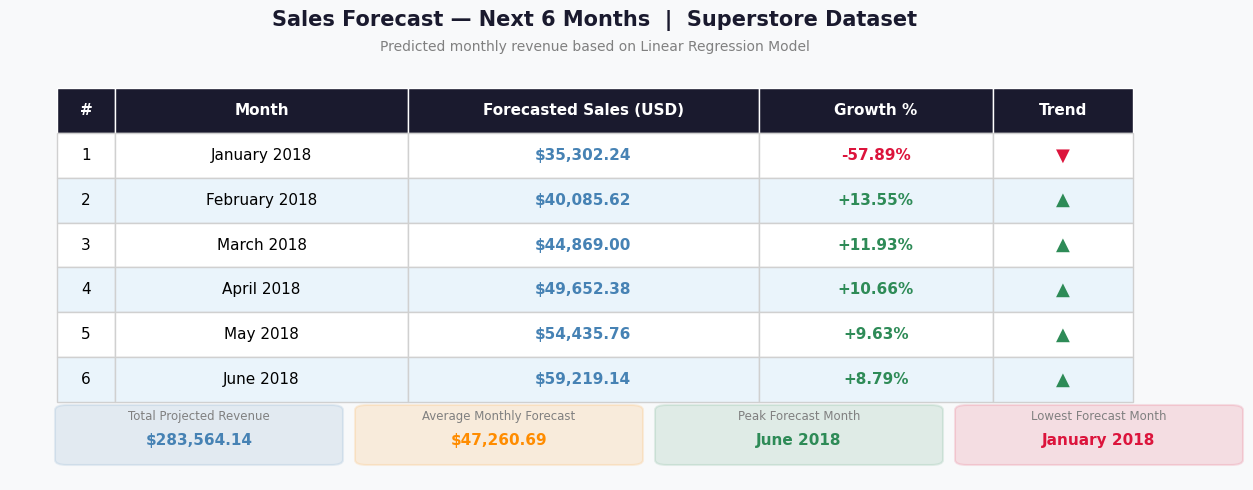

Saved: forecast_table.png


In [68]:
# ── Table Representation — 6 Month Sales Forecast ─────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data Preparation ──────────────────────────────────────────────
months     = [row['Date'].strftime('%B %Y') 
              for _, row in future_df.iterrows()]
forecasted = [row['Forecasted Sales'] 
              for _, row in future_df.iterrows()]

# Calculate month-over-month growth
growth = []
for i in range(len(forecasted)):
    if i == 0:
        # Compare first forecast month with last actual month
        last_actual = monthly_sales['Sales'].iloc[-1]
        pct = ((forecasted[i] - last_actual) / last_actual) * 100
    else:
        pct = ((forecasted[i] - forecasted[i-1]) 
               / forecasted[i-1]) * 100
    growth.append(pct)

# Determine trend arrows
trends = ['▲' if g > 0 else '▼' for g in growth]

# Build table rows
total_forecast = sum(forecasted)
avg_forecast   = total_forecast / len(forecasted)

col_labels = ['#', 'Month', 'Forecasted Sales (USD)',
              'Growth %', 'Trend']

table_data = []
for i in range(len(months)):
    table_data.append([
        str(i + 1),
        months[i],
        f"${forecasted[i]:,.2f}",
        f"{growth[i]:+.2f}%",
        trends[i]
    ])

# ── Build the Figure ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off')

fig.patch.set_facecolor('#f8f9fa')

# Title above table
fig.text(0.5, 0.97,
         'Sales Forecast — Next 6 Months  |  Superstore Dataset',
         ha='center', va='top',
         fontsize=15, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.91,
         'Predicted monthly revenue based on Linear Regression Model',
         ha='center', va='top',
         fontsize=10, color='grey')

# ── Draw the Table ────────────────────────────────────────────────
col_widths = [0.05, 0.25, 0.30, 0.20, 0.12]

table = ax.table(
    cellText    = table_data,
    colLabels   = col_labels,
    cellLoc     = 'center',
    loc         = 'center',
    colWidths   = col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.2)

# ── Style Header Row ──────────────────────────────────────────────
header_color = '#1a1a2e'
for col in range(len(col_labels)):
    cell = table[0, col]
    cell.set_facecolor(header_color)
    cell.set_text_props(color='white',
                        fontweight='bold',
                        fontsize=11)
    cell.set_edgecolor('white')

# ── Style Data Rows ───────────────────────────────────────────────
row_colors = ['#eaf4fb', '#ffffff']   # alternating rows

for row in range(1, len(table_data) + 1):
    for col in range(len(col_labels)):
        cell = table[row, col]
        cell.set_facecolor(row_colors[row % 2])
        cell.set_edgecolor('#d0d0d0')

        # Highlight Sales column in steelblue tone
        if col == 2:
            cell.set_text_props(color='steelblue',
                                fontweight='bold')

        # Color Growth column green/red
        if col == 3:
            g = growth[row - 1]
            cell.set_text_props(
                color='seagreen' if g > 0 else 'crimson',
                fontweight='bold'
            )

        # Color Trend column
        if col == 4:
            g = growth[row - 1]
            cell.set_text_props(
                color='seagreen' if g > 0 else 'crimson',
                fontsize=13,
                fontweight='bold'
            )

# ── Summary Row at Bottom ─────────────────────────────────────────
summary_y = 0.08

summary_boxes = [
    ('Total Projected Revenue',
     f'${total_forecast:,.2f}', 'steelblue'),
    ('Average Monthly Forecast',
     f'${avg_forecast:,.2f}', 'darkorange'),
    ('Peak Forecast Month',
     months[forecasted.index(max(forecasted))], 'seagreen'),
    ('Lowest Forecast Month',
     months[forecasted.index(min(forecasted))], 'crimson'),
]

box_width = 0.22
start_x   = 0.06

for i, (label, value, color) in enumerate(summary_boxes):
    x = start_x + i * (box_width + 0.03)

    # Box background
    fancy = mpatches.FancyBboxPatch(
        (x, summary_y - 0.01), box_width, 0.10,
        boxstyle='round,pad=0.01',
        facecolor=color, alpha=0.12,
        edgecolor=color, linewidth=1.5,
        transform=fig.transFigure, clip_on=False
    )
    fig.add_artist(fancy)

    # Label
    fig.text(x + box_width / 2, summary_y + 0.07,
             label,
             ha='center', fontsize=8.5,
             color='grey', transform=fig.transFigure)

    # Value
    fig.text(x + box_width / 2, summary_y + 0.02,
             value,
             ha='center', fontsize=11,
             fontweight='bold', color=color,
             transform=fig.transFigure)

plt.tight_layout()
plt.savefig('forecast_table.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: forecast_table.png")

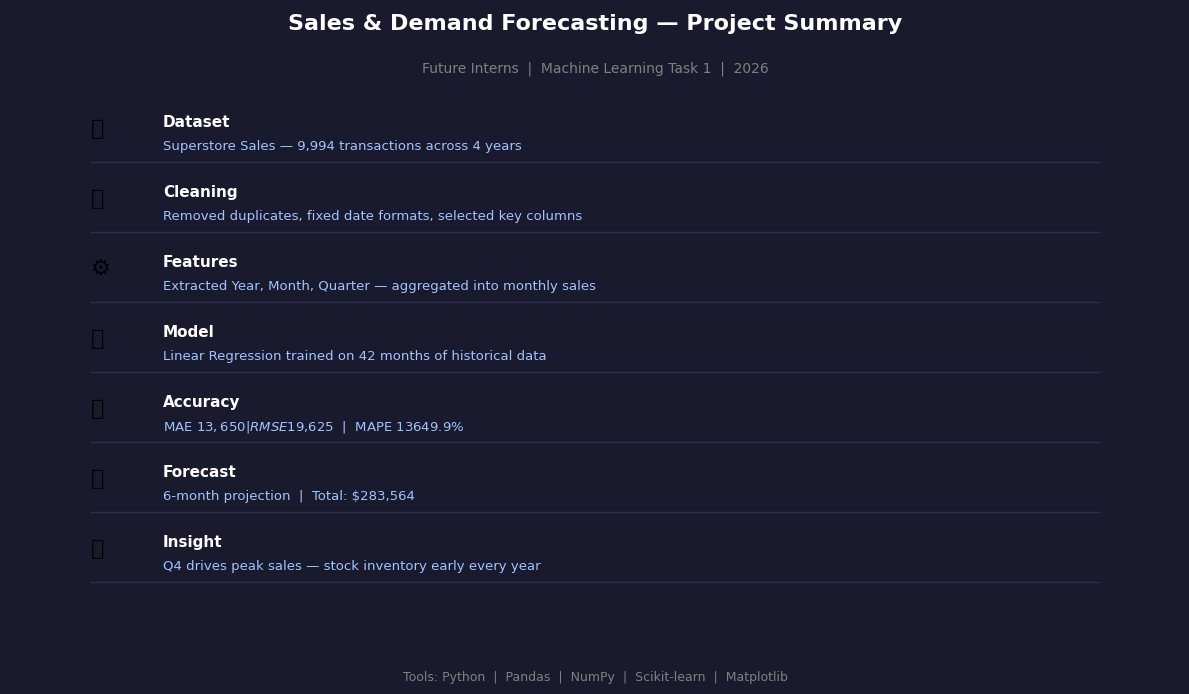

Saved: project_summary.png


In [69]:
# ── Final Business Summary ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')
fig.patch.set_facecolor('#1a1a2e')

# ── Main Title ────────────────────────────────────────────────────
fig.text(0.5, 0.95,
         'Sales & Demand Forecasting — Project Summary',
         ha='center', fontsize=16,
         fontweight='bold', color='white')

fig.text(0.5, 0.89,
         'Future Interns  |  Machine Learning Task 1  |  2026',
         ha='center', fontsize=10, color='grey')

# ── Summary Points ────────────────────────────────────────────────
points = [
    ('📦', 'Dataset',
     'Superstore Sales — 9,994 transactions across 4 years'),
    ('🧹', 'Cleaning',
     'Removed duplicates, fixed date formats, selected key columns'),
    ('⚙️',  'Features',
     'Extracted Year, Month, Quarter — aggregated into monthly sales'),
    ('🤖', 'Model',
     'Linear Regression trained on 42 months of historical data'),
    ('📊', 'Accuracy',
     f'MAE ${mae:,.0f}  |  RMSE ${rmse:,.0f}  |  MAPE {mape:.1f}%'),
    ('🔮', 'Forecast',
     f'6-month projection  |  Total: ${future_df["Forecasted Sales"].sum():,.0f}'),
    ('📈', 'Insight',
     'Q4 drives peak sales — stock inventory early every year'),
]

start_y = 0.80
gap     = 0.10

for emoji, heading, detail in points:
    fig.text(0.08, start_y,
             emoji,
             fontsize=16,
             transform=fig.transFigure)

    fig.text(0.14, start_y + 0.012,
             heading,
             fontsize=11,
             fontweight='bold',
             color='white',
             transform=fig.transFigure)

    fig.text(0.14, start_y - 0.022,
             detail,
             fontsize=9.5,
             color='#a0c4ff',
             transform=fig.transFigure)

    # Divider line
    line = plt.Line2D([0.08, 0.92],
                      [start_y - 0.038,
                       start_y - 0.038],
                      transform=fig.transFigure,
                      color='#2e2e4e', linewidth=1)
    fig.add_artist(line)

    start_y -= gap

# ── Bottom Tag ────────────────────────────────────────────────────
fig.text(0.5, 0.02,
         'Tools: Python  |  Pandas  |  NumPy  |  '
         'Scikit-learn  |  Matplotlib',
         ha='center', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('project_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: project_summary.png")